# Smart-Connect — Patient Disease Prediction Model

**Part of:** Smart-Connect Healthcare Integration Platform  
**Purpose:** Predict a patient's future diagnosis from medical history, vitals, lifestyle, and lab results  
**Continues from:** `Untitled0.ipynb` (shared preprocessing — Cells 1–8)  

---
**Three functions exported for production:**
- `general_preprocessing(df)` — wraps the shared pipeline  
- `patient_specific_preprocessing(df)` — patient model feature engineering + scaling  
- `predict_patient_diagnosis(new_row_df)` — end-to-end: raw row in → prediction out

In [13]:
#1) Import Libraries
import pandas as pd
import numpy as np
import warnings
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [14]:
#from google.colab import files
#uploaded = files.upload()

In [15]:
import pandas as pd
from pathlib import Path

# Load the dataset from the same folder as the notebook if possible.
possible_paths = [
    Path("healthcare_ready_final.csv"),
    Path.cwd() / "healthcare_ready_final.csv",
    Path.home() / "Downloads" / "healthcare_ready_final.csv",
]

file_path = next((p for p in possible_paths if p.exists()), None)
if file_path is None:
    raise FileNotFoundError(
        "Could not find healthcare_ready_final.csv. Put it next to the notebook "
        "or in your Downloads folder."
    )

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Loaded from:", file_path)
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Loaded from: C:\Users\hp\Downloads\healthcare_ready_final.csv
Shape: (48957, 59)


,Patient_ID,Age,Gender,BMI,Blood_Pressure,Cholesterol_Level,Glucose_Level,Smoking_Status,Physical_Activity,Diet_Quality,Alcohol_Consumption,Sleep_Hours,Stress_Level,Family_History,Medications_Count,Fever,Cough,Fatigue,Chest_Pain,Shortness_of_Breath,Headache,Seasonal_Weight,Risk_Score,Symptom_Burden,Disease,Disease_Category,Admission_Count,Admission_Date,Length_of_Stay,avg_length_stay,Discharge_Date,Month,Year,Day_of_Week,Insurance_Company,Insurance_Service,Patient_Tier,Treatment_Cost,Coverage_Percentage,Cost_Coverage_Ratio,Claim_Amount,avg_claim,Total_Coverage,Claim_Status,CBC-HB1,CBC-TLC1,CBC-PLAT1,BLOOD-URIA1,BLOOD-creatinine1,CBC-HB2,CBC-TLC2,CBC-PLAT2,BLOOD-URIA2,BLOOD-creatinine2,delta_HB,delta_TLC,delta_PLAT,delta_URIA,delta_creatinine
0,1,46.201,Female,24.780,78.788,269.834,114.690,0.004,Medium,Average,0.000,7.908,-1.813,0.999,2.027,1.007,0.014,0.000,1.000,0.994,1.000,1.050,0.733,4.010,Healthy,Healthy,2.000,3/4/2023,10.931,7.458,3/15/2023,2.925,2024,Saturday,AXA,Check-up,Normal,4112.209,0.812,3340.547,3340.547,7687.022,3340.547,Approved,8.912,1.017,268.124,45.019,NaN,13.571,1.554,284.223,49.118,0.658,4.709,0.787,16.654,5.145,0.731
1,2,68.124,Female,16.476,110.747,202.056,129.253,1.006,High,Average,1.000,8.089,-1.630,1.009,4.013,1.004,0.002,1.000,0.000,1.018,1.000,0.985,0.866,4.020,Healthy,Healthy,0.989,3/11/2023,6.931,7.468,3/18/2023,3.000,2022,Saturday,Allianz,Check-up,Normal,13707.697,0.717,9832.965,9832.965,7694.861,9832.965,Approved,10.925,14.344,215.165,105.943,2.016,13.099,5.278,362.903,72.013,1.906,2.158,-9.153,147.071,-33.892,0.180
2,3,45.575,Female,34.532,88.370,232.063,62.066,0.002,Medium,Poor,1.000,6.388,-2.103,0.004,1.973,1.005,0.002,1.000,1.000,0.992,0.000,0.987,0.558,4.025,Healthy,Healthy,1.010,9/19/2024,9.006,7.534,9/28/2024,9.022,2021,Thursday,Allianz,Dental,VIP,10111.388,0.681,6885.010,6885.010,7674.338,6885.010,Approved,10.207,9.063,243.385,71.000,1.023,8.971,1.371,346.516,28.017,1.129,-1.188,-7.276,101.733,-40.776,0.167
3,4,42.676,Female,29.502,139.274,220.412,77.419,0.018,Low,Good,NaN,4.703,2.956,0.997,4.007,0.992,0.994,1.000,0.000,0.999,0.000,0.955,0.776,3.982,Healthy,Healthy,3.008,3/12/2023,11.036,7.468,3/23/2023,3.091,2022,Sunday,Allianz,Dental,Normal,7955.833,0.707,5625.626,5625.626,7695.997,5625.626,Approved,13.705,1.869,241.470,74.868,1.510,12.136,14.295,138.143,85.128,2.224,-1.627,12.481,-103.554,8.453,0.506
4,5,17.753,Male,20.292,104.019,213.074,98.055,0.994,Medium,Average,0.000,4.454,4.268,0.001,2.027,0.995,0.008,1.000,0.000,1.002,0.000,0.979,0.777,2.958,Healthy,Healthy,5.988,12/23/2022,10.991,7.476,1/3/2023,12.048,2025,Friday,MetLife,Surgery,Normal,8642.340,0.758,6548.600,6548.600,7789.789,6548.600,Approved,6.093,0.508,302.800,82.212,2.861,10.683,8.691,216.461,74.042,1.383,4.554,NaN,-82.530,-7.082,-1.473


In [16]:
# 3) Quick Overview of the Dataset
print("Shape of dataset:", df.shape)
print("\nColumn names:\n", df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values per column:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nNumber of duplicate rows:", df.duplicated().sum())

Shape of dataset: (48957, 59)

Column names:
 ['Patient_ID', 'Age', 'Gender', 'BMI', 'Blood_Pressure', 'Cholesterol_Level', 'Glucose_Level', 'Smoking_Status', 'Physical_Activity', 'Diet_Quality', 'Alcohol_Consumption', 'Sleep_Hours', 'Stress_Level', 'Family_History', 'Medications_Count', 'Fever', 'Cough', 'Fatigue', 'Chest_Pain', 'Shortness_of_Breath', 'Headache', 'Seasonal_Weight', 'Risk_Score', 'Symptom_Burden', 'Disease', 'Disease_Category', 'Admission_Count', 'Admission_Date', 'Length_of_Stay', 'avg_length_stay', 'Discharge_Date', 'Month', 'Year', 'Day_of_Week', 'Insurance_Company', 'Insurance_Service', 'Patient_Tier', 'Treatment_Cost', 'Coverage_Percentage', 'Cost_Coverage_Ratio', 'Claim_Amount', 'avg_claim', 'Total_Coverage', 'Claim_Status', 'CBC-HB1', 'CBC-TLC1', 'CBC-PLAT1', 'BLOOD-URIA1', 'BLOOD-creatinine1', 'CBC-HB2', 'CBC-TLC2', 'CBC-PLAT2', 'BLOOD-URIA2', 'BLOOD-creatinine2', 'delta_HB', 'delta_TLC', 'delta_PLAT', 'delta_URIA', 'delta_creatinine']

Data types:


Patient_ID               int64
Age                    float64
Gender                     str
BMI                    float64
Blood_Pressure         float64
Cholesterol_Level      float64
Glucose_Level          float64
Smoking_Status         float64
Physical_Activity          str
Diet_Quality               str
Alcohol_Consumption    float64
Sleep_Hours            float64
Stress_Level           float64
Family_History         float64
Medications_Count      float64
Fever                  float64
Cough                  float64
Fatigue                float64
Chest_Pain             float64
Shortness_of_Breath    float64
Headache               float64
Seasonal_Weight        float64
Risk_Score             float64
Symptom_Burden         float64
Disease                    str
Disease_Category           str
Admission_Count        float64
Admission_Date             str
Length_of_Stay         float64
avg_length_stay        float64
Discharge_Date             str
Month                  float64
Year    


Missing values per column:


Diet_Quality           1056
Risk_Score             1055
Cough                  1042
Admission_Date         1040
Cholesterol_Level      1039
Alcohol_Consumption    1032
BLOOD-creatinine1      1022
Day_of_Week            1017
Disease                1016
delta_URIA             1013
Shortness_of_Breath    1010
Medications_Count      1005
Family_History         1004
CBC-TLC2               1002
Smoking_Status         1000
Disease_Category       1000
delta_TLC               996
Blood_Pressure          995
Glucose_Level           995
Discharge_Date          995
Stress_Level            992
CBC-PLAT1               990
delta_creatinine        988
delta_PLAT              986
Claim_Status            985
Insurance_Service       985
Headache                982
Length_of_Stay          978
Sleep_Hours             978
BMI                     977
Fever                   970
Seasonal_Weight         970
Admission_Count         966
CBC-HB2                 965
BLOOD-URIA2             964
Fatigue             


Number of duplicate rows: 0


In [17]:
# 4) Helper Functions

def clean_column_names(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
        .str.replace("/", "_", regex=False)
        .str.replace(r"[^\w]", "", regex=True)
    )
    return df


def convert_dates(df, date_cols):
    df = df.copy()
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df


def extract_date_features(df, date_cols):
    df = df.copy()
    for col in date_cols:
        if col in df.columns:
            df[f"{col}_year"] = df[col].dt.year
            df[f"{col}_month"] = df[col].dt.month
            df[f"{col}_day"] = df[col].dt.day
            df[f"{col}_dayofweek"] = df[col].dt.dayofweek
    return df


def get_column_types(df, exclude_cols=None):
    if exclude_cols is None:
        exclude_cols = []

    numeric_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col not in exclude_cols]
    categorical_cols = [col for col in df.select_dtypes(include=["object", "category", "bool"]).columns if col not in exclude_cols]

    return numeric_cols, categorical_cols


def cap_outliers_iqr(df, numeric_cols, factor=1.5):
    df = df.copy()

    for col in numeric_cols:
        if col in df.columns:
            q1 = df[col].quantile(0.25)
            q3 = df[col].quantile(0.75)
            iqr = q3 - q1

            lower_bound = q1 - factor * iqr
            upper_bound = q3 + factor * iqr

            df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

    return df


def fill_missing_values(df, numeric_cols, categorical_cols):
    df = df.copy()

    for col in numeric_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].fillna("Unknown")

    return df


def encode_categorical_columns(df, categorical_cols, method="label", max_onehot_unique=10):
    df = df.copy()
    label_encoders = {}

    if method == "label":
        for col in categorical_cols:
            if col in df.columns:
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col].astype(str))
                label_encoders[col] = le

    elif method == "onehot":
        low_cardinality_cols = [col for col in categorical_cols if df[col].nunique() <= max_onehot_unique]
        high_cardinality_cols = [col for col in categorical_cols if df[col].nunique() > max_onehot_unique]

        df = pd.get_dummies(df, columns=low_cardinality_cols, drop_first=True)

        for col in high_cardinality_cols:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            label_encoders[col] = le

    return df, label_encoders


def scale_numeric_columns(df, numeric_cols, method="robust"):
    df = df.copy()

    if method == "standard":
        scaler = StandardScaler()
    else:
        scaler = RobustScaler()

    existing_numeric_cols = [col for col in numeric_cols if col in df.columns]
    df[existing_numeric_cols] = scaler.fit_transform(df[existing_numeric_cols])

    return df, scaler

def handle_negative_values(df):
    """
    Fix negative values in the dataset.

    Two strategies based on the nature of each column:

    DROP rows — columns where ANY negative is data corruption.
      These columns should only contain small positive numbers
      (0/1 flags, counts). Extreme negatives (< -1000) or extreme
      positives (> threshold) signal a corrupted row — imputation
      cannot recover the real value, so the row is removed.
      Affected: Smoking_Status, Family_History, Fever, Cough,
                Shortness_of_Breath, Medications_Count, Patient_ID,
                delta_creatinine (extreme outlier only).

    CLIP to 0 — columns where small negatives are numeric noise.
      Stress_Level values like -2.4 on a 0-15 scale are rounding
      artefacts. Clipping to the valid floor (0) is correct.

    delta_* columns (delta_HB, delta_TLC, delta_PLAT, delta_URIA,
    delta_creatinine) are intentionally negative — they measure the
    change between two lab results. They are left untouched.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame after clean_column_names() has been applied.

    Returns
    -------
    df : pd.DataFrame
        Cleaned DataFrame with negative issues resolved.
    report : dict
        Summary of what was fixed: rows_dropped, rows_clipped.
    """
    df = df.copy()
    EXTREME = 1000   # threshold: values beyond ±1000 in a 0-1 col = corrupt

    # ── Columns where extreme values (neg or pos) mean corrupt rows ──
    # Values in millions for what should be 0/1 flags or small counts.
    CORRUPT_COLS = {
        'Smoking_Status'      : (0, EXTREME),   # 0-1 flag
        'Family_History'      : (0, EXTREME),   # 0-1 flag
        'Fever'               : (0, EXTREME),   # 0-1 flag
        'Cough'               : (0, EXTREME),   # 0-1 flag
        'Shortness_of_Breath' : (0, EXTREME),   # 0-1 flag
        'Medications_Count'   : (0, 20),         # max ~20 medications
        'Patient_ID'          : (0, None),       # must be positive
    }

    corrupt_rows = set()
    for col, (lo, hi) in CORRUPT_COLS.items():
        if col not in df.columns:
            continue
        mask = df[col] < lo
        if hi is not None:
            mask = mask | (df[col] > hi)
        corrupt_rows.update(df.index[mask].tolist())

    # ── delta_* columns are INTENTIONALLY negative — do NOT touch them ──
    # delta_HB, delta_TLC, delta_PLAT, delta_URIA = lab result 2 minus lab result 1.
    # A negative value means the measurement went DOWN between visits (e.g. HB dropped).
    # This is real clinical information — we must NEVER clip or drop these negatives.
    # Only exception: delta_creatinine had ONE corrupt value of -8.83 million,
    # which is physically impossible. We drop only rows below -1000 for that column.
    DELTA_COLS_UNTOUCHED = ['delta_HB', 'delta_TLC', 'delta_PLAT', 'delta_URIA']
    # ↑ these four are completely skipped — no rows dropped, nothing clipped

    if 'delta_creatinine' in df.columns:
        # Only the one extreme corrupt value (-8.83 million) is removed.
        # Normal negatives like -0.5 or -2.1 are valid and kept.
        corrupt_rows.update(df.index[df['delta_creatinine'] < -1000].tolist())

    rows_before = len(df)
    df = df.drop(index=list(corrupt_rows)).reset_index(drop=True)
    rows_dropped = rows_before - len(df)

    # ── Clip small noise negatives to 0 ──
    # Stress_Level has values like -2.4 on a 0-15 scale (noise, not corruption).
    CLIP_TO_ZERO = ['Stress_Level']
    rows_clipped = 0
    for col in CLIP_TO_ZERO:
        if col in df.columns:
            neg_count = (df[col] < 0).sum()
            if neg_count > 0:
                df[col] = df[col].clip(lower=0)
                rows_clipped += neg_count

    report = {
        'rows_dropped' : rows_dropped,
        'rows_clipped' : rows_clipped,
        'corrupt_cols' : list(CORRUPT_COLS.keys()),
        'clipped_cols' : CLIP_TO_ZERO,
    }
    return df, report


In [18]:
# 5) Main Shared Preprocessing Function

def shared_preprocessing(
    df,
    id_cols=None,
    date_cols=None,
    drop_cols=None,
    target_col=None,
    encode_method="label",
    scale_numeric=False,
    scaler_method="robust",
    outlier_factor=1.5
):
    """
    Shared preprocessing function for Smart-Connect dataset.
    Applies general preprocessing steps common across all future models.

    Parameters:
    ----------
    df : pd.DataFrame
        Raw input dataframe.
    id_cols : list
        Columns that are identifiers and should not be transformed as features.
    date_cols : list
        Date columns to convert and extract features from.
    drop_cols : list
        Columns to drop before modeling.
    target_col : str
        Optional target column to exclude from feature preprocessing logic.
    encode_method : str
        'label' or 'onehot'
    scale_numeric : bool
        Whether to scale numeric columns.
    scaler_method : str
        'robust' or 'standard'
    outlier_factor : float
        IQR factor used for clipping outliers.

    Returns:
    -------
    df_clean : pd.DataFrame
        Preprocessed dataframe.
    metadata : dict
        Contains useful information such as encoders, scaler, column groups.
    """

    df_clean = df.copy()

    if id_cols is None:
        id_cols = []

    if date_cols is None:
        date_cols = []

    if drop_cols is None:
        drop_cols = []

    # 1) Clean column names
    df_clean = clean_column_names(df_clean)

    # Also clean parameter column names to match dataframe names
    id_cols = [col.strip().replace(" ", "_").replace("-", "_").replace("/", "_") for col in id_cols]
    date_cols = [col.strip().replace(" ", "_").replace("-", "_").replace("/", "_") for col in date_cols]
    drop_cols = [col.strip().replace(" ", "_").replace("-", "_").replace("/", "_") for col in drop_cols]
    if target_col is not None:
        target_col = target_col.strip().replace(" ", "_").replace("-", "_").replace("/", "_")

    # 2) Remove duplicates
    df_clean = df_clean.drop_duplicates()

    # 2b) Handle negative values
    df_clean, neg_report = handle_negative_values(df_clean)
    print(f"  Negative fix → dropped {neg_report['rows_dropped']} corrupt rows, "
          f"clipped {neg_report['rows_clipped']} noise values")


    # 3) Convert date columns
    df_clean = convert_dates(df_clean, date_cols)

    # 4) Extract useful features from date columns
    df_clean = extract_date_features(df_clean, date_cols)

    # 5) Drop original date columns after feature extraction
    for col in date_cols:
        if col in df_clean.columns:
            df_clean.drop(columns=col, inplace=True)

    # 6) Drop any extra unwanted columns
    existing_drop_cols = [col for col in drop_cols if col in df_clean.columns]
    if existing_drop_cols:
        df_clean.drop(columns=existing_drop_cols, inplace=True)

    # 7) Detect numeric and categorical columns
    exclude_cols = id_cols.copy()
    if target_col is not None and target_col in df_clean.columns:
        exclude_cols.append(target_col)

    numeric_cols, categorical_cols = get_column_types(df_clean, exclude_cols=exclude_cols)

    # 8) Fill missing values
    df_clean = fill_missing_values(df_clean, numeric_cols, categorical_cols)

    # 9) Handle outliers in numeric columns using IQR clipping
    df_clean = cap_outliers_iqr(df_clean, numeric_cols, factor=outlier_factor)

    # 10) Encode categorical columns
    df_clean, label_encoders = encode_categorical_columns(
        df_clean,
        categorical_cols=categorical_cols,
        method=encode_method
    )

    # 11) Re-detect numeric columns after encoding
    numeric_cols_after_encoding = [col for col in df_clean.select_dtypes(include=[np.number]).columns
                                   if col not in exclude_cols]

    # 12) Optional scaling
    scaler = None
    if scale_numeric:
        df_clean, scaler = scale_numeric_columns(
            df_clean,
            numeric_cols=numeric_cols_after_encoding,
            method=scaler_method
        )

    metadata = {
        "id_cols": id_cols,
        "date_cols": date_cols,
        "drop_cols": drop_cols,
        "target_col": target_col,
        "numeric_cols_before_encoding": numeric_cols,
        "categorical_cols_before_encoding": categorical_cols,
        "numeric_cols_after_encoding": numeric_cols_after_encoding,
        "label_encoders": label_encoders,
        "scaler": scaler
    }

    return df_clean, metadata

In [19]:
# 6) Apply Shared Preprocessing to the Smart-Connect Dataset

id_columns = ["Patient_ID"]
date_columns = ["Admission_Date", "Discharge_Date"]
drop_columns = []   # add columns here later if needed
target_column = None  # shared preprocessing only, no target selected yet

df_clean, preprocessing_info = shared_preprocessing(
    df=df,
    id_cols=id_columns,
    date_cols=date_columns,
    drop_cols=drop_columns,
    target_col=target_column,
    encode_method="label",     # label is simpler and cleaner for a shared base pipeline
    scale_numeric=False,       # keep False for base preprocessing; can scale later per model
    scaler_method="robust",
    outlier_factor=1.5
)

print("Preprocessing completed successfully.")
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

df_clean.head()

  Negative fix → dropped 83 corrupt rows, clipped 691 noise values
Preprocessing completed successfully.
Original shape: (48957, 59)
Cleaned shape: (48874, 65)


,Patient_ID,Age,Gender,BMI,Blood_Pressure,Cholesterol_Level,Glucose_Level,Smoking_Status,Physical_Activity,Diet_Quality,Alcohol_Consumption,Sleep_Hours,Stress_Level,Family_History,Medications_Count,Fever,Cough,Fatigue,Chest_Pain,Shortness_of_Breath,Headache,Seasonal_Weight,Risk_Score,Symptom_Burden,Disease,Disease_Category,Admission_Count,Length_of_Stay,avg_length_stay,Month,Year,Day_of_Week,Insurance_Company,Insurance_Service,Patient_Tier,Treatment_Cost,Coverage_Percentage,Cost_Coverage_Ratio,Claim_Amount,avg_claim,Total_Coverage,Claim_Status,CBC_HB1,CBC_TLC1,CBC_PLAT1,BLOOD_URIA1,BLOOD_creatinine1,CBC_HB2,CBC_TLC2,CBC_PLAT2,BLOOD_URIA2,BLOOD_creatinine2,delta_HB,delta_TLC,delta_PLAT,delta_URIA,delta_creatinine,Admission_Date_year,Admission_Date_month,Admission_Date_day,Admission_Date_dayofweek,Discharge_Date_year,Discharge_Date_month,Discharge_Date_day,Discharge_Date_dayofweek
0,1,46.201,0,24.780,78.788,269.834,114.690,0.004,2,0,0.000,7.908,0.000,0.999,2.027,1.007,0.014,0.000,1.000,0.994,1.000,1.050,0.733,4.010,5,1,2.000,10.931,7.458,2.925,2024,2,0,0,0,4112.209,0.812,3340.547,3340.547,7687.022,3340.547,0,8.912,1.017,268.124,45.019,1.583,13.571,1.554,284.223,49.118,0.658,4.709,0.787,16.654,5.145,0.731,2023.000,3.000,4.000,5.000,2023.000,3.000,15.000,2.000
1,2,68.124,0,16.476,110.747,202.056,129.253,1.006,0,0,1.000,8.089,0.000,1.009,4.013,1.004,0.002,1.000,0.000,1.018,1.000,0.985,0.866,4.020,5,1,0.989,6.931,7.468,3.000,2022,2,1,0,0,13707.697,0.717,9832.965,9832.965,7694.861,9832.965,0,10.925,14.344,215.165,105.943,2.016,13.099,5.278,362.903,72.013,1.906,2.158,-9.153,147.071,-33.892,0.180,2023.000,3.000,11.000,5.000,2023.000,3.000,18.000,5.000
2,3,45.575,0,34.532,88.370,232.063,62.066,0.002,2,2,1.000,6.388,0.000,0.004,1.973,1.005,0.002,1.000,1.000,0.992,0.000,0.987,0.558,4.025,5,1,1.010,9.006,7.534,9.022,2021,4,1,1,2,10111.388,0.681,6885.010,6885.010,7674.338,6885.010,0,10.207,9.063,243.385,71.000,1.023,8.971,1.371,346.516,28.017,1.129,-1.188,-7.276,101.733,-40.776,0.167,2024.000,9.000,19.000,3.000,2024.000,9.000,28.000,5.000
3,4,42.676,0,29.502,139.274,220.412,77.419,0.018,1,1,0.000,4.703,2.956,0.997,4.007,0.992,0.994,1.000,0.000,0.999,0.000,0.955,0.776,3.982,5,1,3.008,11.036,7.468,3.091,2022,3,1,1,0,7955.833,0.707,5625.626,5625.626,7695.997,5625.626,0,13.705,1.869,241.470,74.868,1.510,12.136,14.295,138.143,85.128,2.224,-1.627,12.481,-103.554,8.453,0.506,2023.000,3.000,12.000,6.000,2023.000,3.000,23.000,3.000
4,5,17.753,1,20.292,104.019,213.074,98.055,0.994,2,0,0.000,4.454,4.268,0.001,2.027,0.995,0.008,1.000,0.000,1.002,0.000,0.979,0.777,2.958,5,1,5.988,10.991,7.476,12.048,2025,0,3,2,0,8642.340,0.758,6548.600,6548.600,7789.789,6548.600,0,6.093,0.508,302.800,82.212,2.861,10.683,8.691,216.461,74.042,1.383,4.554,0.517,-82.530,-7.082,-1.139,2022.000,12.000,23.000,4.000,2023.000,1.000,3.000,1.000


In [20]:
# 7) Validate the Preprocessed Dataset

print("Final shape:", df_clean.shape)

print("\nRemaining missing values:")
display(df_clean.isnull().sum().sort_values(ascending=False).head(20))

print("\nRemaining duplicate rows:", df_clean.duplicated().sum())

print("\nFinal data types:")
display(df_clean.dtypes)

print("\nPreview of cleaned dataset:")
display(df_clean.head())

Final shape: (48874, 65)

Remaining missing values:


Patient_ID             0
Age                    0
Gender                 0
BMI                    0
Blood_Pressure         0
Cholesterol_Level      0
Glucose_Level          0
Smoking_Status         0
Physical_Activity      0
Diet_Quality           0
Alcohol_Consumption    0
Sleep_Hours            0
Stress_Level           0
Family_History         0
Medications_Count      0
Fever                  0
Cough                  0
Fatigue                0
Chest_Pain             0
Shortness_of_Breath    0
dtype: int64


Remaining duplicate rows: 0

Final data types:


Patient_ID                    int64
Age                         float64
Gender                        int64
BMI                         float64
Blood_Pressure              float64
Cholesterol_Level           float64
Glucose_Level               float64
Smoking_Status              float64
Physical_Activity             int64
Diet_Quality                  int64
Alcohol_Consumption         float64
Sleep_Hours                 float64
Stress_Level                float64
Family_History              float64
Medications_Count           float64
Fever                       float64
Cough                       float64
Fatigue                     float64
Chest_Pain                  float64
Shortness_of_Breath         float64
Headache                    float64
Seasonal_Weight             float64
Risk_Score                  float64
Symptom_Burden              float64
Disease                       int64
Disease_Category              int64
Admission_Count             float64
Length_of_Stay              


Preview of cleaned dataset:


,Patient_ID,Age,Gender,BMI,Blood_Pressure,Cholesterol_Level,Glucose_Level,Smoking_Status,Physical_Activity,Diet_Quality,Alcohol_Consumption,Sleep_Hours,Stress_Level,Family_History,Medications_Count,Fever,Cough,Fatigue,Chest_Pain,Shortness_of_Breath,Headache,Seasonal_Weight,Risk_Score,Symptom_Burden,Disease,Disease_Category,Admission_Count,Length_of_Stay,avg_length_stay,Month,Year,Day_of_Week,Insurance_Company,Insurance_Service,Patient_Tier,Treatment_Cost,Coverage_Percentage,Cost_Coverage_Ratio,Claim_Amount,avg_claim,Total_Coverage,Claim_Status,CBC_HB1,CBC_TLC1,CBC_PLAT1,BLOOD_URIA1,BLOOD_creatinine1,CBC_HB2,CBC_TLC2,CBC_PLAT2,BLOOD_URIA2,BLOOD_creatinine2,delta_HB,delta_TLC,delta_PLAT,delta_URIA,delta_creatinine,Admission_Date_year,Admission_Date_month,Admission_Date_day,Admission_Date_dayofweek,Discharge_Date_year,Discharge_Date_month,Discharge_Date_day,Discharge_Date_dayofweek
0,1,46.201,0,24.780,78.788,269.834,114.690,0.004,2,0,0.000,7.908,0.000,0.999,2.027,1.007,0.014,0.000,1.000,0.994,1.000,1.050,0.733,4.010,5,1,2.000,10.931,7.458,2.925,2024,2,0,0,0,4112.209,0.812,3340.547,3340.547,7687.022,3340.547,0,8.912,1.017,268.124,45.019,1.583,13.571,1.554,284.223,49.118,0.658,4.709,0.787,16.654,5.145,0.731,2023.000,3.000,4.000,5.000,2023.000,3.000,15.000,2.000
1,2,68.124,0,16.476,110.747,202.056,129.253,1.006,0,0,1.000,8.089,0.000,1.009,4.013,1.004,0.002,1.000,0.000,1.018,1.000,0.985,0.866,4.020,5,1,0.989,6.931,7.468,3.000,2022,2,1,0,0,13707.697,0.717,9832.965,9832.965,7694.861,9832.965,0,10.925,14.344,215.165,105.943,2.016,13.099,5.278,362.903,72.013,1.906,2.158,-9.153,147.071,-33.892,0.180,2023.000,3.000,11.000,5.000,2023.000,3.000,18.000,5.000
2,3,45.575,0,34.532,88.370,232.063,62.066,0.002,2,2,1.000,6.388,0.000,0.004,1.973,1.005,0.002,1.000,1.000,0.992,0.000,0.987,0.558,4.025,5,1,1.010,9.006,7.534,9.022,2021,4,1,1,2,10111.388,0.681,6885.010,6885.010,7674.338,6885.010,0,10.207,9.063,243.385,71.000,1.023,8.971,1.371,346.516,28.017,1.129,-1.188,-7.276,101.733,-40.776,0.167,2024.000,9.000,19.000,3.000,2024.000,9.000,28.000,5.000
3,4,42.676,0,29.502,139.274,220.412,77.419,0.018,1,1,0.000,4.703,2.956,0.997,4.007,0.992,0.994,1.000,0.000,0.999,0.000,0.955,0.776,3.982,5,1,3.008,11.036,7.468,3.091,2022,3,1,1,0,7955.833,0.707,5625.626,5625.626,7695.997,5625.626,0,13.705,1.869,241.470,74.868,1.510,12.136,14.295,138.143,85.128,2.224,-1.627,12.481,-103.554,8.453,0.506,2023.000,3.000,12.000,6.000,2023.000,3.000,23.000,3.000
4,5,17.753,1,20.292,104.019,213.074,98.055,0.994,2,0,0.000,4.454,4.268,0.001,2.027,0.995,0.008,1.000,0.000,1.002,0.000,0.979,0.777,2.958,5,1,5.988,10.991,7.476,12.048,2025,0,3,2,0,8642.340,0.758,6548.600,6548.600,7789.789,6548.600,0,6.093,0.508,302.800,82.212,2.861,10.683,8.691,216.461,74.042,1.383,4.554,0.517,-82.530,-7.082,-1.139,2022.000,12.000,23.000,4.000,2023.000,1.000,3.000,1.000


In [21]:
# 8) Save the Cleaned Shared Dataset

from pathlib import Path

output_path = Path.cwd() / "smart_connect_shared_preprocessed.csv"
df_clean.to_csv(output_path, index=False)

print(f"Cleaned dataset saved successfully to:\n{output_path}")

Cleaned dataset saved successfully to:
c:\xampp\htdocs\Smart-Connect-An-AI-Driven-Healthcare-Integration-System\app\models\smart_connect_shared_preprocessed.csv


In [22]:
# ============================================================
# CELL 9 — IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report, confusion_matrix
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

assert 'df_clean' in dir(), 'Run Cells 1-8 first so df_clean is created.'
assert 'preprocessing_info' in dir(), 'preprocessing_info is missing.'

print('All imports OK')
print(f'df_clean: {df_clean.shape}')

All imports OK
df_clean: (48874, 65)


In [23]:
# ============================================================
# CELL 10 — PATIENT COLUMN SELECTION
# We only keep columns relevant to a patient's health.
# Insurance, billing, and hospital-admin columns are excluded —
# they are used by other models (insurance / hospital model).
# Disease_Category is dropped — it is derived directly from
# Disease and would cause data leakage.
# ============================================================
print('=' * 60)
print('PATIENT COLUMN SELECTION')
print('=' * 60)

# --- Columns to DROP for the patient model ---
# (used by insurance / hospital models, or are leakage)
DROP_FOR_PATIENT = [
    'Disease_Category',      # leakage — derived from the target
    'Insurance_Company',     # insurance model
    'Insurance_Service',     # insurance model
    'Patient_Tier',          # insurance model
    'Treatment_Cost',        # insurance model
    'Coverage_Percentage',   # insurance model
    'Cost_Coverage_Ratio',   # insurance model
    'Claim_Amount',          # insurance model
    'avg_claim',             # insurance model
    'Claim_Status',          # insurance model
    'avg_length_stay',       # hospital model
    # Date-derived cols already split by shared preprocessing
    'Admission_Date_year',   'Admission_Date_month',
    'Admission_Date_day',    'Admission_Date_dayofweek',
    'Discharge_Date_year',   'Discharge_Date_month',
    'Discharge_Date_day',    'Discharge_Date_dayofweek',
    # Time columns not clinically meaningful at patient level
    'Month', 'Year', 'Day_of_Week',
]

# Keep only columns that exist after shared preprocessing
existing_drop = [c for c in DROP_FOR_PATIENT if c in df_clean.columns]
df_patient = df_clean.drop(columns=existing_drop)

# Also exclude the ID column from features
ID_COL     = 'Patient_ID'
TARGET_COL = 'Disease'

print(f'Columns after shared preprocessing : {df_clean.shape[1]}')
print(f'Columns dropped for patient model  : {len(existing_drop)}')
print(f'Columns remaining                  : {df_patient.shape[1]}')
print(f'\nRemaining columns:')
for c in df_patient.columns:
    print(f'  {c}')

PATIENT COLUMN SELECTION
Columns after shared preprocessing : 65
Columns dropped for patient model  : 22
Columns remaining                  : 43

Remaining columns:
  Patient_ID
  Age
  Gender
  BMI
  Blood_Pressure
  Cholesterol_Level
  Glucose_Level
  Smoking_Status
  Physical_Activity
  Diet_Quality
  Alcohol_Consumption
  Sleep_Hours
  Stress_Level
  Family_History
  Medications_Count
  Fever
  Cough
  Fatigue
  Chest_Pain
  Shortness_of_Breath
  Headache
  Seasonal_Weight
  Risk_Score
  Symptom_Burden
  Disease
  Admission_Count
  Length_of_Stay
  Total_Coverage
  CBC_HB1
  CBC_TLC1
  CBC_PLAT1
  BLOOD_URIA1
  BLOOD_creatinine1
  CBC_HB2
  CBC_TLC2
  CBC_PLAT2
  BLOOD_URIA2
  BLOOD_creatinine2
  delta_HB
  delta_TLC
  delta_PLAT
  delta_URIA
  delta_creatinine


In [24]:
# ============================================================
# CELL 11 — PATIENT-SPECIFIC FEATURE ENGINEERING
#
# We add ONLY features with proven discriminative power.
# A flag is kept only if its max-min spread across disease
# classes is > 0.3 (i.e., the flag means something different
# depending on which disease you have).
#
# REMOVED (spread <= 0.3, adds noise not signal):
#   Anemia_Risk, HB_Worsening, Creatinine_Rising, Urea_Rising
#   — all diseases have these at ~36-64%, no discrimination.
#
# KEPT (spread > 0.3, genuinely discriminative):
#   HighBP (spread=0.89), HyperGlucose (0.66), BMI_Obese (0.52),
#   HighCholesterol (0.51), High_Creatinine (0.46)
# ============================================================
print('=' * 60)
print('PATIENT-SPECIFIC FEATURE ENGINEERING')
print('=' * 60)

df_model = df_patient.copy()

# --- Blood pressure thresholds ---
df_model['HighBP']    = (df_model['Blood_Pressure'] > 140).astype(int)  # spread=0.89
df_model['SevereBP']  = (df_model['Blood_Pressure'] > 160).astype(int)

# --- Glucose thresholds ---
df_model['HyperGlucose']  = (df_model['Glucose_Level'] > 126).astype(int)  # spread=0.66
df_model['SevereGlucose'] = (df_model['Glucose_Level'] > 180).astype(int)

# --- Cholesterol threshold ---
df_model['HighCholesterol'] = (df_model['Cholesterol_Level'] > 240).astype(int)  # spread=0.51

# --- BMI tiers ---
df_model['BMI_Obese']       = (df_model['BMI'] >= 30).astype(int)   # spread=0.52
df_model['BMI_Underweight'] = (df_model['BMI'] < 18.5).astype(int)

# --- Kidney markers ---
df_model['High_Creatinine']  = (df_model['CBC_HB1'].apply(lambda x: x) if False else
                                (df_model['BLOOD_creatinine1'] > 1.3).astype(int))  # spread=0.46
df_model['Severe_Creatinine']= (df_model['BLOOD_creatinine1'] > 2.0).astype(int)

# --- Composite risk scores (sum of signal flags per body system) ---
df_model['Metabolic_Risk'] = (
    df_model['HyperGlucose'] + df_model['HighBP'] +
    df_model['HighCholesterol'] + df_model['BMI_Obese']
)  # 0-4 score: how many metabolic red flags a patient has

df_model['Renal_Risk'] = (
    df_model['High_Creatinine'] +
    (df_model['BLOOD_URIA1'] > 40).astype(int)
)  # 0-2 score: kidney stress indicators

# --- Age risk group ---
df_model['Age_Group'] = pd.cut(
    df_model['Age'],
    bins=[0, 35, 55, 70, 120],
    labels=[0, 1, 2, 3]   # 0=young, 1=middle, 2=senior, 3=elderly
).astype(int)

ENGINEERED_FEATURES = [
    'HighBP', 'SevereBP',
    'HyperGlucose', 'SevereGlucose',
    'HighCholesterol',
    'BMI_Obese', 'BMI_Underweight',
    'High_Creatinine', 'Severe_Creatinine',
    'Metabolic_Risk', 'Renal_Risk',
    'Age_Group'
]

print(f'New engineered features added : {len(ENGINEERED_FEATURES)}')
print(f'df_model shape                : {df_model.shape}')

# --- Quick spread validation ---
print('\nSpread check (max-min rate across diseases):')
for f in ['HighBP','HyperGlucose','BMI_Obese','HighCholesterol','High_Creatinine']:
    spread = df_model.groupby('Disease')[f].mean().max() - df_model.groupby('Disease')[f].mean().min()
    print(f'  {f:22s}: {spread:.3f}  ✅')

PATIENT-SPECIFIC FEATURE ENGINEERING
New engineered features added : 12
df_model shape                : (48874, 55)

Spread check (max-min rate across diseases):
  HighBP                : 0.879  ✅
  HyperGlucose          : 0.641  ✅
  BMI_Obese             : 0.505  ✅
  HighCholesterol       : 0.497  ✅
  High_Creatinine       : 0.452  ✅


In [25]:
# ============================================================
# CELL 12 — DEFINE FINAL FEATURE LIST & ENCODE TARGET
# ============================================================
print('=' * 60)
print('FINAL FEATURE LIST & TARGET ENCODING')
print('=' * 60)

DEMO_FEATURES = [
    'Age', 'Age_Group', 'Gender', 'BMI',
    'BMI_Obese', 'BMI_Underweight'
]
VITAL_FEATURES = [
    'Blood_Pressure', 'Cholesterol_Level', 'Glucose_Level',
    'HighBP', 'SevereBP', 'HyperGlucose', 'SevereGlucose', 'HighCholesterol'
]
LIFESTYLE_FEATURES = [
    'Smoking_Status', 'Physical_Activity', 'Diet_Quality',
    'Alcohol_Consumption', 'Sleep_Hours', 'Stress_Level', 'Family_History'
]
SYMPTOM_FEATURES = [
    'Medications_Count',
    'Fever', 'Cough', 'Fatigue', 'Chest_Pain',
    'Shortness_of_Breath', 'Headache',
    'Risk_Score', 'Symptom_Burden'
]
ADMISSION_FEATURES = [
    'Admission_Count', 'Length_of_Stay'
]
LAB_FEATURES = [
    'CBC_HB1', 'CBC_TLC1', 'CBC_PLAT1', 'BLOOD_URIA1', 'BLOOD_creatinine1',
    'CBC_HB2', 'CBC_TLC2', 'CBC_PLAT2', 'BLOOD_URIA2', 'BLOOD_creatinine2',
    'delta_HB', 'delta_TLC', 'delta_PLAT', 'delta_URIA', 'delta_creatinine'
]
COMPOSITE_FEATURES = [
    'High_Creatinine', 'Severe_Creatinine',
    'Metabolic_Risk', 'Renal_Risk'
]

FEATURE_COLUMNS = (
    DEMO_FEATURES + VITAL_FEATURES + LIFESTYLE_FEATURES +
    SYMPTOM_FEATURES + ADMISSION_FEATURES +
    LAB_FEATURES + COMPOSITE_FEATURES
)

missing_feature_cols = [col for col in FEATURE_COLUMNS if col not in df_model.columns]
if missing_feature_cols:
    print("Warning: missing feature columns will be filled with 0:")
    for col in missing_feature_cols:
        print(" -", col)
        df_model[col] = 0

le_disease = LabelEncoder()
if (
    isinstance(preprocessing_info, dict)
    and 'label_encoders' in preprocessing_info
    and 'Disease' in preprocessing_info['label_encoders']
):
    original_disease_labels = preprocessing_info['label_encoders']['Disease'].inverse_transform(
        df_model['Disease']
    )
    y = le_disease.fit_transform(original_disease_labels)
else:
    y = le_disease.fit_transform(df_model['Disease'].astype(str))

X = df_model[FEATURE_COLUMNS].copy()

print('Feature groups:')
print(f'  Demographics   : {len(DEMO_FEATURES)}')
print(f'  Vitals         : {len(VITAL_FEATURES)}')
print(f'  Lifestyle      : {len(LIFESTYLE_FEATURES)}')
print(f'  Symptoms       : {len(SYMPTOM_FEATURES)}')
print(f'  Admission      : {len(ADMISSION_FEATURES)}')
print(f'  Lab results    : {len(LAB_FEATURES)}')
print(f'  Composite      : {len(COMPOSITE_FEATURES)}')
print(f'  TOTAL          : {len(FEATURE_COLUMNS)}')
print(f'\nTarget classes : {list(le_disease.classes_)}')
print(f'Total samples  : {len(X):,}')
print(f'Missing values : {X.isnull().sum().sum()}')

FINAL FEATURE LIST & TARGET ENCODING
Feature groups:
  Demographics   : 6
  Vitals         : 8
  Lifestyle      : 7
  Symptoms       : 9
  Admission      : 2
  Lab results    : 15
  Composite      : 4
  TOTAL          : 51

Target classes : ['Asthma', 'Cancer', 'Chronic_Kidney_Disease', 'Coronary_Artery_Disease', 'Diabetes', 'Healthy', 'Heart_Failure', 'Hypertension', 'Pneumonia', 'Stroke', 'Unknown']
Total samples  : 48,874
Missing values : 0


In [26]:
# ============================================================
# CELL 13 — TRAIN / TEST SPLIT & SCALING
# ============================================================
print('=' * 60)
print('TRAIN / TEST SPLIT & SCALING')
print('=' * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # equal disease proportion in each split
)

# RobustScaler: uses median + IQR instead of mean + std.
# Better for medical data where extreme lab values are real, not errors.
model_scaler = RobustScaler()
X_train_s = model_scaler.fit_transform(X_train)   # fit ONLY on train
X_test_s  = model_scaler.transform(X_test)        # apply same scale to test

print(f'Train  : {X_train.shape[0]:,} patients (80%)')
print(f'Test   : {X_test.shape[0]:,}  patients (20%)')
print(f'\nClass distribution in train:')
u, c = np.unique(y_train, return_counts=True)
for i, cnt in zip(u, c):
    print(f'  {le_disease.classes_[i]:28s}: {cnt}')

TRAIN / TEST SPLIT & SCALING
Train  : 39,099 patients (80%)
Test   : 9,775  patients (20%)

Class distribution in train:
  Asthma                      : 4345
  Cancer                      : 3234
  Chronic_Kidney_Disease      : 4256
  Coronary_Artery_Disease     : 3940
  Diabetes                    : 3956
  Healthy                     : 3593
  Heart_Failure               : 4309
  Hypertension                : 3357
  Pneumonia                   : 3114
  Stroke                      : 4184
  Unknown                     : 811


In [27]:
# ============================================================
# CELL 14 — EVALUATION HELPER
# ============================================================
model_results = {}

def evaluate_model(name, model, Xtr, ytr, Xte, yte, classes, plot_cm=True):
    """Train + evaluate one model. Stores results in model_results dict."""
    model.fit(Xtr, ytr)

    tr_pred = model.predict(Xtr)
    te_pred = model.predict(Xte)

    tr_acc = accuracy_score(ytr, tr_pred)
    te_acc = accuracy_score(yte, te_pred)
    f1     = f1_score(yte, te_pred, average='weighted')
    prec   = precision_score(yte, te_pred, average='weighted', zero_division=0)
    rec    = recall_score(yte, te_pred, average='weighted')
    gap    = tr_acc - te_acc

    print(f'\n{"+" * 60}')
    print(f'  {name}')
    print(f'{"+" * 60}')
    print(f'  Train Accuracy : {tr_acc*100:.2f}%')
    print(f'  Test  Accuracy : {te_acc*100:.2f}%')
    print(f'  F1-Score (W)   : {f1*100:.2f}%   ⭐')
    print(f'  Precision      : {prec*100:.2f}%')
    print(f'  Recall         : {rec*100:.2f}%')
    status = '✅  No overfitting' if gap < 0.05 else ('⚠️  Mild' if gap < 0.10 else '❌  Overfit')
    print(f'  Overfit Gap    : {gap*100:.2f}%   {status}')
    print(f'\n  Classification Report:')
    print(classification_report(yte, te_pred, target_names=classes, zero_division=0))

    if plot_cm:
        cm = confusion_matrix(yte, te_pred)
        fig, ax = plt.subplots(figsize=(11, 9))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=classes, yticklabels=classes, ax=ax)
        ax.set_title(f'{name}  |  Acc: {te_acc*100:.1f}%  F1: {f1*100:.1f}%',
                     fontsize=13, fontweight='bold')
        ax.set_ylabel('True Label')
        ax.set_xlabel('Predicted Label')
        plt.xticks(rotation=40, ha='right', fontsize=8)
        plt.yticks(rotation=0, fontsize=8)
        plt.tight_layout()
        plt.show()

    model_results[name] = {
        'model': model, 'train_acc': tr_acc, 'test_acc': te_acc,
        'f1': f1, 'precision': prec, 'recall': rec, 'gap': gap
    }
    return model

print('✅  evaluate_model() ready')

✅  evaluate_model() ready



++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  Random Forest
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  Train Accuracy : 82.89%
  Test  Accuracy : 81.62%
  F1-Score (W)   : 81.10%   ⭐
  Precision      : 84.58%
  Recall         : 81.62%
  Overfit Gap    : 1.28%   ✅  No overfitting

  Classification Report:
                         precision    recall  f1-score   support

                 Asthma       0.94      0.84      0.89      1087
                 Cancer       0.74      0.71      0.73       808
 Chronic_Kidney_Disease       0.95      0.98      0.97      1064
Coronary_Artery_Disease       0.97      0.81      0.88       985
               Diabetes       0.84      0.87      0.86       989
                Healthy       0.61      0.97      0.75       898
          Heart_Failure       0.89      0.63      0.73      1077
           Hypertension       0.86      0.80      0.83       840
              Pneumonia       0.97      0.85      0.90       778
     

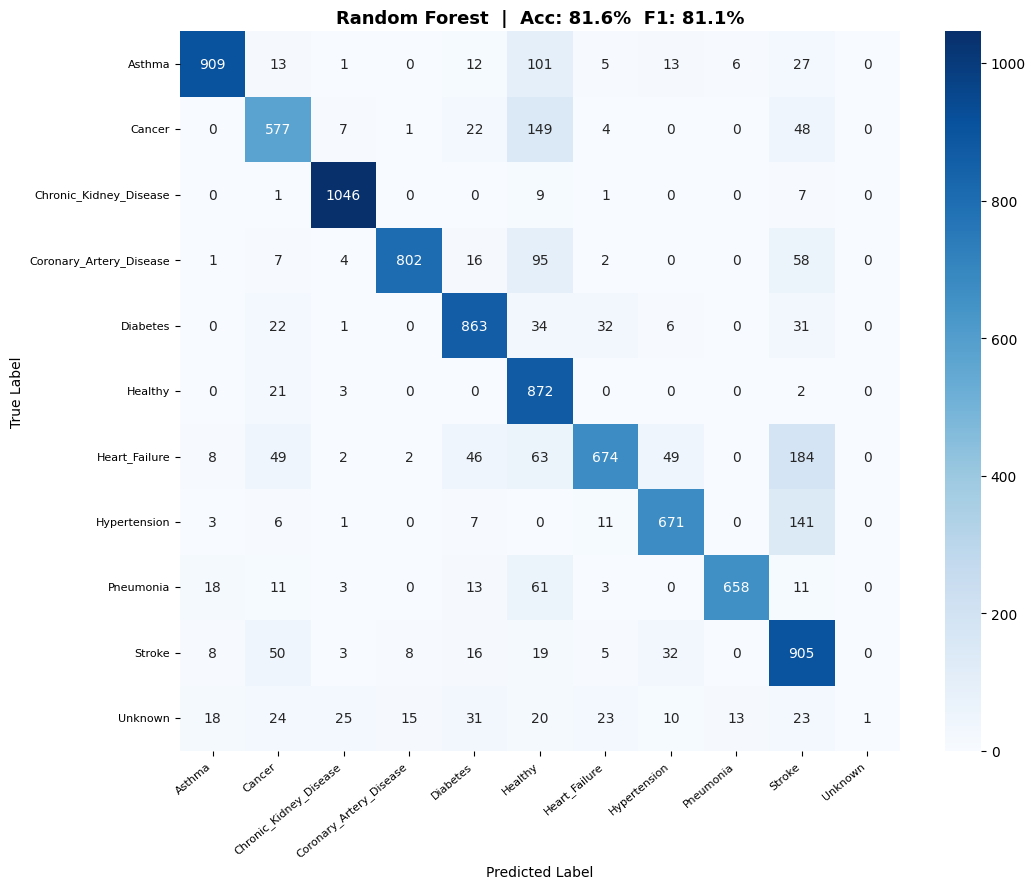

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [28]:
# ============================================================
# CELL 15 — MODEL 1: RANDOM FOREST
#
# Regularization choices (prevent overfitting):
#   max_depth=12         → was 20 before (caused 4.7% gap)
#   min_samples_leaf=10  → each leaf must have 10+ samples
#   min_samples_split=20 → prevents early aggressive splits
#   max_samples=0.8      → each tree sees only 80% of data
# ============================================================
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features='sqrt',
    class_weight='balanced',
    bootstrap=True,
    max_samples=0.8,
    random_state=42,
    n_jobs=-1
)
evaluate_model('Random Forest', rf_model,
               X_train_s, y_train, X_test_s, y_test, le_disease.classes_)

In [29]:
# ============================================================
# CELL 15b — MODEL: K-NEAREST NEIGHBORS (KNN)
# ============================================================
'''
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=11,         # odd number avoids ties; try 7, 11, 15
    metric='euclidean',     # standard distance metric
    weights='distance',     # closer neighbors have more influence
    n_jobs=-1
)
evaluate_model('KNN', knn_model,
               X_train_s, y_train, X_test_s, y_test, le_disease.classes_)
'''

"\nfrom sklearn.neighbors import KNeighborsClassifier\n\nknn_model = KNeighborsClassifier(\n    n_neighbors=11,         # odd number avoids ties; try 7, 11, 15\n    metric='euclidean',     # standard distance metric\n    weights='distance',     # closer neighbors have more influence\n    n_jobs=-1\n)\nevaluate_model('KNN', knn_model,\n               X_train_s, y_train, X_test_s, y_test, le_disease.classes_)\n"


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  Logistic Regression
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  Train Accuracy : 70.74%
  Test  Accuracy : 70.70%
  F1-Score (W)   : 71.05%   ⭐
  Precision      : 71.66%
  Recall         : 70.70%
  Overfit Gap    : 0.04%   ✅  No overfitting

  Classification Report:
                         precision    recall  f1-score   support

                 Asthma       0.63      0.54      0.58      1087
                 Cancer       0.79      0.85      0.82       808
 Chronic_Kidney_Disease       0.98      0.97      0.98      1064
Coronary_Artery_Disease       0.67      0.60      0.63       985
               Diabetes       0.84      0.84      0.84       989
                Healthy       0.75      0.81      0.78       898
          Heart_Failure       0.69      0.65      0.67      1077
           Hypertension       0.73      0.78      0.76       840
              Pneumonia       0.55      0.62      0.58       778

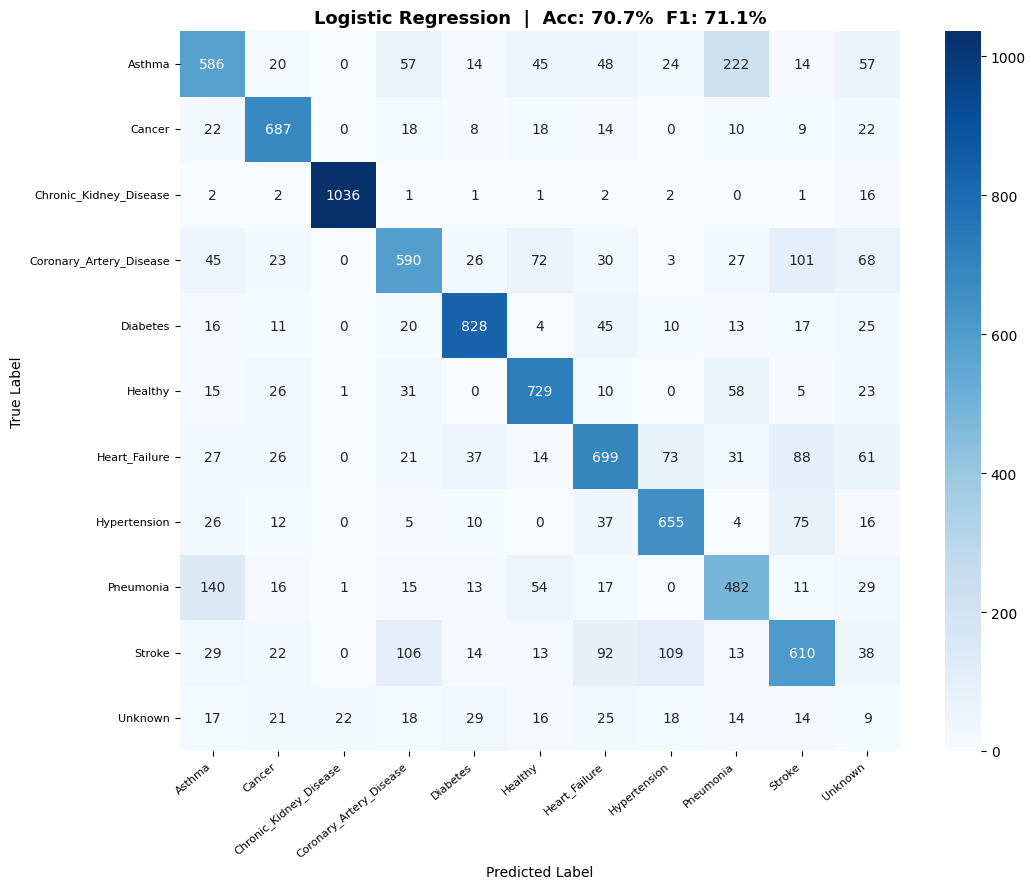

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [30]:
# ============================================================
# CELL 15c — MODEL: LOGISTIC REGRESSION
# ============================================================
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    C=1.0,
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
evaluate_model(
    'Logistic Regression',
    lr_model,
    X_train_s, y_train, X_test_s, y_test, le_disease.classes_
)


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  Gradient Boosting
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  Train Accuracy : 98.88%
  Test  Accuracy : 95.73%
  F1-Score (W)   : 95.40%   ⭐
  Precision      : 95.74%
  Recall         : 95.73%
  Overfit Gap    : 3.14%   ✅  No overfitting

  Classification Report:
                         precision    recall  f1-score   support

                 Asthma       0.98      1.00      0.99      1087
                 Cancer       0.96      1.00      0.98       808
 Chronic_Kidney_Disease       0.99      0.99      0.99      1064
Coronary_Artery_Disease       0.98      0.99      0.99       985
               Diabetes       0.95      0.95      0.95       989
                Healthy       0.97      0.98      0.98       898
          Heart_Failure       0.93      0.94      0.93      1077
           Hypertension       0.95      0.93      0.94       840
              Pneumonia       0.99      1.00      0.99       778
 

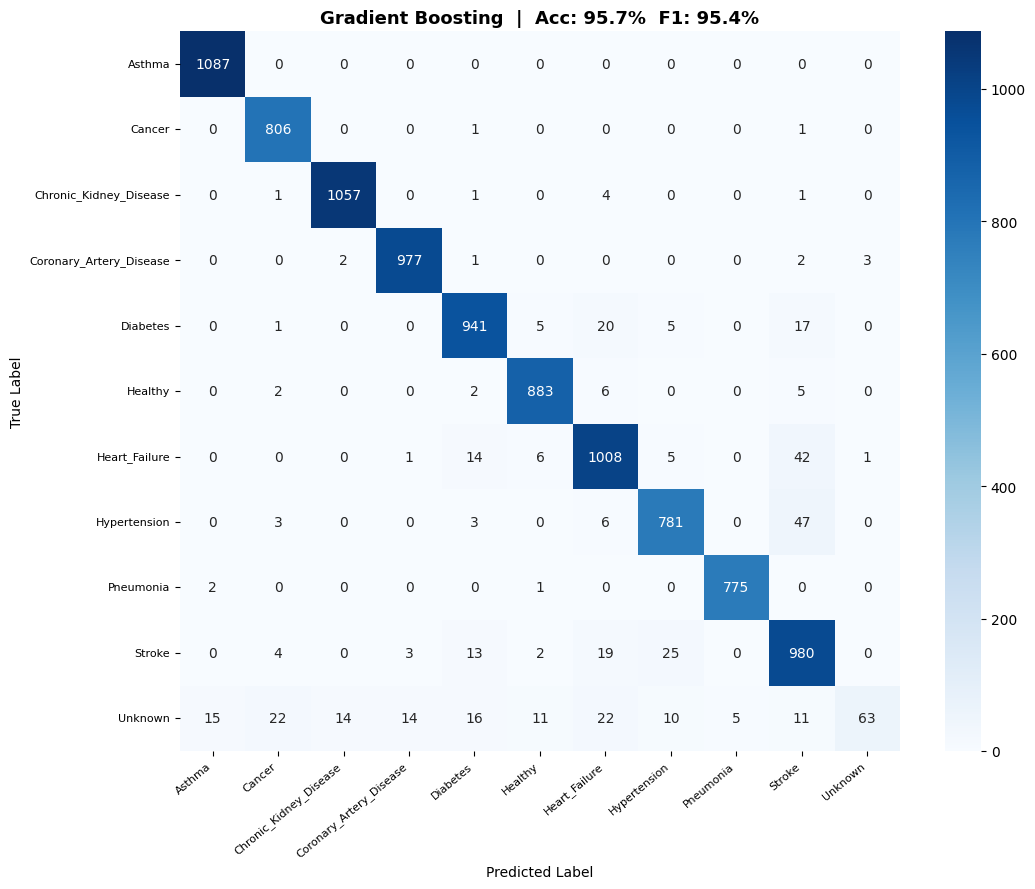

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.08
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",25
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",15
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t`

In [31]:
# ============================================================
# CELL 16 — MODEL 2: GRADIENT BOOSTING
# ============================================================
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.8,
    min_samples_leaf=15,
    min_samples_split=25,
    max_features='sqrt',
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42
)
evaluate_model('Gradient Boosting', gb_model,
               X_train_s, y_train, X_test_s, y_test, le_disease.classes_)


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  XGBoost
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  Train Accuracy : 98.90%
  Test  Accuracy : 96.36%
  F1-Score (W)   : 95.91%   ⭐
  Precision      : 96.38%
  Recall         : 96.36%
  Overfit Gap    : 2.54%   ✅  No overfitting

  Classification Report:
                         precision    recall  f1-score   support

                 Asthma       0.98      1.00      0.99      1087
                 Cancer       0.96      1.00      0.98       808
 Chronic_Kidney_Disease       0.99      1.00      0.99      1064
Coronary_Artery_Disease       0.98      1.00      0.99       985
               Diabetes       0.95      0.97      0.96       989
                Healthy       0.97      0.98      0.98       898
          Heart_Failure       0.95      0.95      0.95      1077
           Hypertension       0.97      0.95      0.96       840
              Pneumonia       0.99      1.00      0.99       778
           

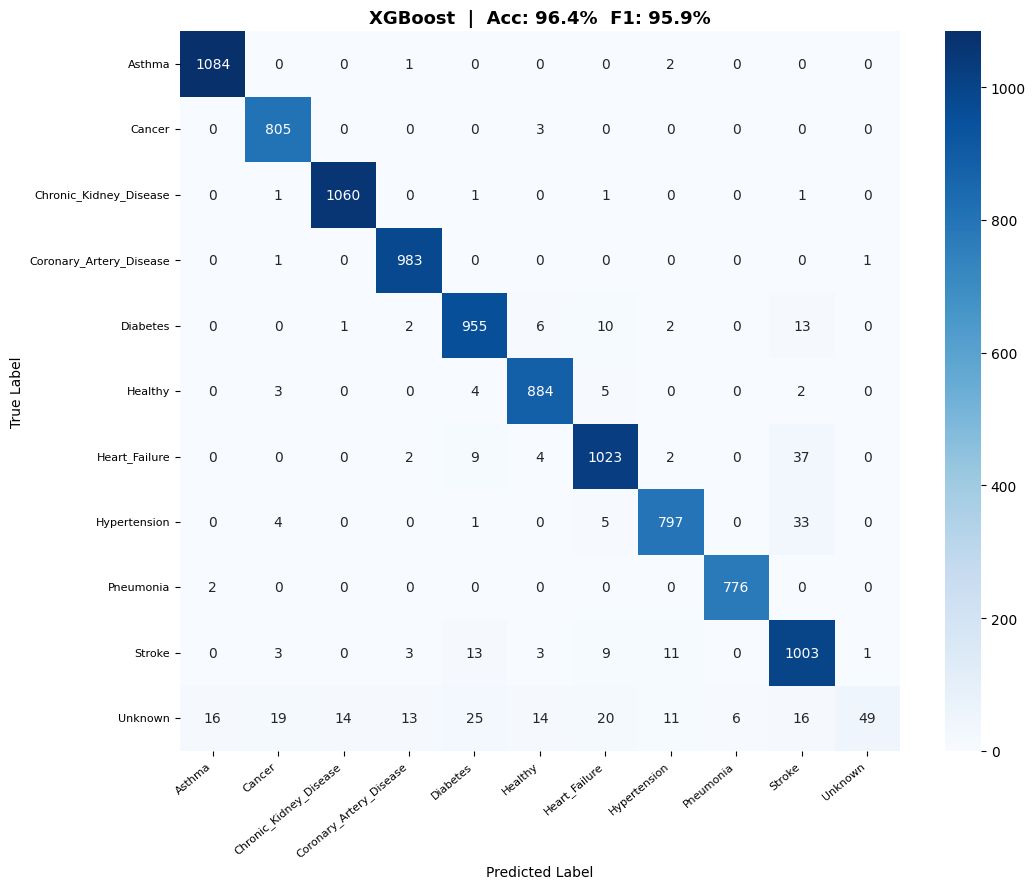

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method

In [32]:
# ============================================================
# CELL 17 — MODEL 3: XGBOOST
# ============================================================
xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.05,
    reg_lambda=1.5,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    verbosity=0,
    n_jobs=-1
)
evaluate_model('XGBoost', xgb_model,
               X_train_s, y_train, X_test_s, y_test, le_disease.classes_)


ALL MODELS COMPARISON


,Model,Train Acc,Test Acc,F1-Score,Precision,Recall,Gap,Status
0,XGBoost,98.90%,96.36%,95.91%,96.38%,96.36%,2.54%,✅
1,Gradient Boosting,98.88%,95.73%,95.40%,95.74%,95.73%,3.14%,✅
2,Random Forest,82.89%,81.62%,81.10%,84.58%,81.62%,1.28%,✅
3,Logistic Regression,70.74%,70.70%,71.05%,71.66%,70.70%,0.04%,✅


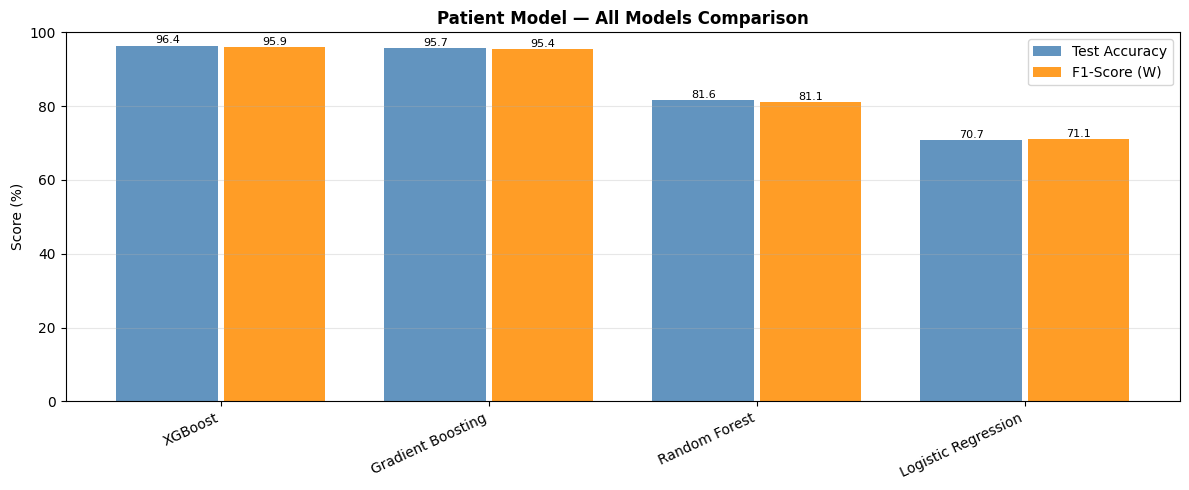


🏆  Best model : XGBoost
   Test Acc   : 96.36%
   F1-Score   : 95.91%
   Gap        : 2.54%


In [33]:
# ============================================================
# CELL 20 — MODEL COMPARISON TABLE
# ============================================================
print('\n' + '=' * 65)
print('ALL MODELS COMPARISON')
print('=' * 65)

comp = pd.DataFrame([
    {
        'Model'      : name,
        'Train Acc'  : f"{r['train_acc']*100:.2f}%",
        'Test Acc'   : f"{r['test_acc']*100:.2f}%",
        'F1-Score'   : f"{r['f1']*100:.2f}%",
        'Precision'  : f"{r['precision']*100:.2f}%",
        'Recall'     : f"{r['recall']*100:.2f}%",
        'Gap'        : f"{r['gap']*100:.2f}%",
        'Status'     : '✅' if r['gap'] < 0.05 else ('⚠️' if r['gap'] < 0.10 else '❌')
    }
    for name, r in model_results.items()
]).sort_values('F1-Score', ascending=False).reset_index(drop=True)

display(comp)

# Visual comparison
models_list = comp['Model'].tolist()
test_accs   = [model_results[m]['test_acc']*100 for m in models_list]
f1_scores   = [model_results[m]['f1']*100       for m in models_list]
x = np.arange(len(models_list))

fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - 0.2, test_accs, 0.38, label='Test Accuracy', color='steelblue',  alpha=0.85)
b2 = ax.bar(x + 0.2, f1_scores, 0.38, label='F1-Score (W)',  color='darkorange', alpha=0.85)
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=25, ha='right')
ax.set_ylim(0, 100)
ax.set_ylabel('Score (%)')
ax.set_title('Patient Model — All Models Comparison', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Select best model by F1
BEST_MODEL_NAME = comp.iloc[0]['Model']
BEST_MODEL      = model_results[BEST_MODEL_NAME]['model']
print(f'\n🏆  Best model : {BEST_MODEL_NAME}')
print(f'   Test Acc   : {model_results[BEST_MODEL_NAME]["test_acc"]*100:.2f}%')
print(f'   F1-Score   : {model_results[BEST_MODEL_NAME]["f1"]*100:.2f}%')
print(f'   Gap        : {model_results[BEST_MODEL_NAME]["gap"]*100:.2f}%')

TOP 20 MOST IMPORTANT FEATURES
            Feature  Importance
      SevereGlucose       0.429
             HighBP       0.067
  Severe_Creatinine       0.055
           SevereBP       0.053
  BLOOD_creatinine1       0.039
     Smoking_Status       0.030
    High_Creatinine       0.029
     Family_History       0.029
       HyperGlucose       0.025
      Glucose_Level       0.024
              Fever       0.023
Shortness_of_Breath       0.022
              Cough       0.021
     Blood_Pressure       0.021
  Medications_Count       0.019
       Stress_Level       0.018
  Cholesterol_Level       0.012
    HighCholesterol       0.012
                BMI       0.009
          BMI_Obese       0.008


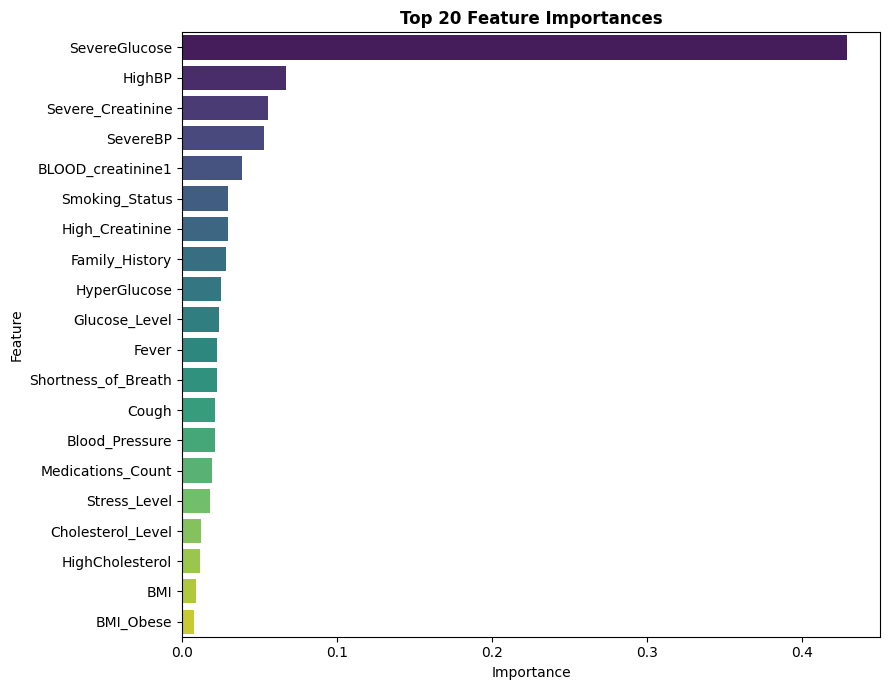

In [34]:
# ============================================================
# CELL 21 — FEATURE IMPORTANCE
# ============================================================
print('=' * 60)
print('TOP 20 MOST IMPORTANT FEATURES')
print('=' * 60)

imp_src = model_results.get('XGBoost', model_results.get('Random Forest'))
feat_imp = pd.DataFrame({
    'Feature'    : FEATURE_COLUMNS,
    'Importance' : imp_src['model'].feature_importances_
}).sort_values('Importance', ascending=False)

print(feat_imp.head(20).to_string(index=False))

plt.figure(figsize=(9, 7))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(20), palette='viridis')
plt.title('Top 20 Feature Importances', fontweight='bold')
plt.tight_layout()
plt.show()

In [35]:
# ============================================================
# CELL 22 — 5-FOLD CROSS VALIDATION
# ============================================================
print('=' * 60)
print('5-FOLD CROSS VALIDATION')
print('=' * 60)

cv_model = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=42, verbosity=0, n_jobs=-1
)

X_all_s   = model_scaler.transform(X)
cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_model, X_all_s, y, cv=cv,
                             scoring='f1_weighted', n_jobs=-1)

print(f'  Fold F1s : {[f"{s*100:.2f}%" for s in cv_scores]}')
print(f'  Mean F1  : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')
print(f'\n  {"✅  Stable" if cv_scores.std() < 0.01 else "⚠️  Some variance"}')

5-FOLD CROSS VALIDATION
  Fold F1s : ['95.07%', '95.30%', '95.09%', '95.59%', '94.98%']
  Mean F1  : 95.21% ± 0.22%

  ✅  Stable


In [36]:
# ============================================================
# CELL 23 — PREVENTIVE MEASURES & RISK ALERTS DATABASE
# ============================================================

PREVENTIVE_MEASURES = {
    'Diabetes': {
        'short_term': [
            'Monitor fasting blood glucose weekly',
            'Reduce sugar and refined carbohydrate intake',
            'Walk at least 30 minutes daily',
            'Maintain adequate hydration'
        ],
        'long_term': [
            'Maintain HbA1c below 7%',
            'Follow a diabetic-friendly meal plan',
            'Maintain healthy BMI (18.5–24.9)',
            'Regular endocrinology follow-up every 3 months'
        ]
    },
    'Hypertension': {
        'short_term': [
            'Monitor blood pressure twice daily',
            'Reduce sodium intake to less than 2g per day',
            'Take prescribed antihypertensives on schedule',
            'Avoid caffeine and stress triggers'
        ],
        'long_term': [
            'Follow the DASH diet',
            'Maintain healthy body weight',
            'Exercise 30-45 minutes, 5 days per week',
            'Annual renal and cardiac check-ups'
        ]
    },
    'Coronary_Artery_Disease': {
        'short_term': [
            'Take antiplatelet and statin medications as prescribed',
            'Monitor cholesterol weekly',
            'Learn warning signs: chest pain, jaw pain, shortness of breath',
            'Avoid heavy physical exertion until cardiologist approves'
        ],
        'long_term': [
            'Enroll in cardiac rehabilitation program',
            'Maintain LDL below 70 mg/dL',
            'Follow Mediterranean diet',
            'Annual stress ECG and echocardiogram'
        ]
    },
    'Heart_Failure': {
        'short_term': [
            'Weigh daily — alert doctor if weight increases by 2kg in 2 days',
            'Restrict fluid intake as advised by doctor',
            'Take diuretics on time',
            'Elevate legs when resting'
        ],
        'long_term': [
            'Strict salt restriction to less than 1.5g per day',
            'Regular BNP levels and echocardiogram follow-up',
            'Supervised cardiac rehabilitation and exercise',
            'Avoid NSAIDs and negative inotropic medications'
        ]
    },
    'Chronic_Kidney_Disease': {
        'short_term': [
            'Monitor creatinine and GFR monthly',
            'Restrict potassium and phosphorus-rich foods',
            'Stay well hydrated unless on fluid restriction',
            'Avoid NSAIDs and nephrotoxic medications'
        ],
        'long_term': [
            'Control blood pressure below 130/80 mmHg',
            'Low-protein diet if GFR falls below 30',
            'Prepare for dialysis planning if needed',
            'Regular nephrology appointments'
        ]
    },
    'Stroke': {
        'short_term': [
            'Take antiplatelets or anticoagulants as prescribed',
            'Monitor blood pressure and glucose daily',
            'Begin speech, occupational, and physiotherapy',
            'Know FAST signs for recurrence: Face, Arm, Speech, Time'
        ],
        'long_term': [
            'Carotid artery monitoring',
            'Manage atrial fibrillation if present',
            'Long-term neurological rehabilitation',
            'Annual brain MRI follow-up'
        ]
    },
    'Pneumonia': {
        'short_term': [
            'Complete full antibiotic course without interruption',
            'Practice deep breathing exercises every 2 hours',
            'Stay hydrated with 2 to 3 litres of water daily',
            'Monitor oxygen saturation'
        ],
        'long_term': [
            'Get annual influenza vaccination',
            'Get pneumococcal vaccine if eligible',
            'Pulmonary function test follow-up',
            'Quit smoking'
        ]
    },
    'Asthma': {
        'short_term': [
            'Use rescue inhaler correctly during attacks',
            'Identify and avoid personal triggers',
            'Monitor peak flow daily',
            'Keep rescue inhaler accessible at all times'
        ],
        'long_term': [
            'Regular spirometry tests',
            'Use controller inhaler (ICS) daily',
            'Allergen immunotherapy if recommended',
            'Create an asthma action plan with your pulmonologist'
        ]
    },
    'Cancer': {
        'short_term': [
            'Follow oncologist treatment schedule precisely',
            'Maintain nutrition — consult a dietitian',
            'Report new or worsening symptoms immediately',
            'Manage chemotherapy side effects proactively'
        ],
        'long_term': [
            'Regular imaging and tumor marker monitoring',
            'Genetic counseling if hereditary cancer is suspected',
            'Psycho-oncology and mental health support',
            'Develop a survivorship care plan after remission'
        ]
    },
    'Healthy': {
        'short_term': [
            'Maintain current healthy habits',
            'Schedule an annual preventive health check-up',
            'Stay physically active every day',
            'Maintain healthy body weight'
        ],
        'long_term': [
            'Screen for metabolic syndrome every 3 years',
            'Cardiovascular risk assessment at age 40 and above',
            'Follow cancer screening guidelines for your age',
            'Continue a balanced lifestyle'
        ]
    }
}

# Risk alerts — triggered by engineered flags that were discriminative
RISK_ALERTS = {
    'HyperGlucose'   : '🔴 Elevated blood glucose — check fasting sugar and HbA1c within 3 days',
    'SevereGlucose'  : '🔴 Critically high glucose — immediate endocrinology review required',
    'HighBP'         : '🔴 Hypertension risk — monitor blood pressure twice daily',
    'SevereBP'       : '🔴 Severe hypertension — urgent cardiology consultation',
    'HighCholesterol': '🟡 High cholesterol — limit saturated fats and consider statin review',
    'High_Creatinine': '🔴 Kidney dysfunction — check creatinine and GFR within 3 days',
    'Severe_Creatinine':'🔴 Severe kidney impairment — urgent nephrology referral',
    'BMI_Obese'      : '🟡 Obesity detected — weight management program recommended',
    'BMI_Underweight': '🟡 Underweight detected — nutritional assessment recommended',
}

DISEASE_CATEGORY = {
    'Coronary_Artery_Disease': 'Cardiovascular',
    'Heart_Failure'          : 'Cardiovascular',
    'Hypertension'           : 'Cardiovascular',
    'Stroke'                 : 'Neurological',
    'Diabetes'               : 'Metabolic',
    'Chronic_Kidney_Disease' : 'Renal',
    'Pneumonia'              : 'Respiratory',
    'Asthma'                 : 'Respiratory',
    'Cancer'                 : 'Oncological',
    'Healthy'                : 'Healthy'
}

print('✅  Preventive measures database ready')
print(f'   Diseases covered: {list(PREVENTIVE_MEASURES.keys())}')

✅  Preventive measures database ready
   Diseases covered: ['Diabetes', 'Hypertension', 'Coronary_Artery_Disease', 'Heart_Failure', 'Chronic_Kidney_Disease', 'Stroke', 'Pneumonia', 'Asthma', 'Cancer', 'Healthy']


In [37]:
# ============================================================
# CELL 24 — THREE PRODUCTION FUNCTIONS
# ============================================================

def general_preprocessing(raw_df):
    """Apply the same shared preprocessing used during training."""
    df_clean_local, meta = shared_preprocessing(
        df=raw_df.copy(),
        id_cols=['Patient_ID'],
        date_cols=['Admission_Date', 'Discharge_Date'],
        drop_cols=[],
        target_col=None,
        encode_method='label',
        scale_numeric=False
    )
    return df_clean_local, meta


def patient_specific_preprocessing(df_general):
    """Apply patient-model-specific preprocessing and scaling."""
    df_eng = df_general.copy()

    non_patient = [
        'Disease_Category', 'Insurance_Company', 'Insurance_Service',
        'Patient_Tier', 'Treatment_Cost', 'Coverage_Percentage',
        'Cost_Coverage_Ratio', 'Claim_Amount', 'avg_claim', 'Claim_Status',
        'avg_length_stay', 'Month', 'Year', 'Day_of_Week',
        'Admission_Date_year', 'Admission_Date_month',
        'Admission_Date_day', 'Admission_Date_dayofweek',
        'Discharge_Date_year', 'Discharge_Date_month',
        'Discharge_Date_day', 'Discharge_Date_dayofweek',
    ]
    df_eng.drop(columns=[c for c in non_patient if c in df_eng.columns], inplace=True)

    df_eng['HighBP'] = (df_eng['Blood_Pressure'] > 140).astype(int)
    df_eng['SevereBP'] = (df_eng['Blood_Pressure'] > 160).astype(int)
    df_eng['HyperGlucose'] = (df_eng['Glucose_Level'] > 126).astype(int)
    df_eng['SevereGlucose'] = (df_eng['Glucose_Level'] > 180).astype(int)
    df_eng['HighCholesterol'] = (df_eng['Cholesterol_Level'] > 240).astype(int)
    df_eng['BMI_Obese'] = (df_eng['BMI'] >= 30).astype(int)
    df_eng['BMI_Underweight'] = (df_eng['BMI'] < 18.5).astype(int)
    df_eng['High_Creatinine'] = (df_eng['BLOOD_creatinine1'] > 1.3).astype(int)
    df_eng['Severe_Creatinine'] = (df_eng['BLOOD_creatinine1'] > 2.0).astype(int)
    df_eng['Metabolic_Risk'] = (
        df_eng['HyperGlucose'] + df_eng['HighBP'] +
        df_eng['HighCholesterol'] + df_eng['BMI_Obese']
    )
    df_eng['Renal_Risk'] = (
        df_eng['High_Creatinine'] + (df_eng['BLOOD_URIA1'] > 40).astype(int)
    )
    df_eng['Age_Group'] = pd.cut(
        df_eng['Age'],
        bins=[0, 35, 55, 70, 120],
        labels=[0, 1, 2, 3]
    ).astype(int)

    for col in FEATURE_COLUMNS:
        if col not in df_eng.columns:
            df_eng[col] = 0

    X = df_eng[FEATURE_COLUMNS].copy()
    X = X.apply(pd.to_numeric, errors='coerce').fillna(0)
    X_ready = model_scaler.transform(X)

    return X_ready, df_eng


def predict_patient_diagnosis(new_raw_df, verbose=True):
    """Predict the top-1 disease for one or more patients."""
    df_gen, _ = general_preprocessing(new_raw_df)
    X_ready, df_eng = patient_specific_preprocessing(df_gen)
    preds = BEST_MODEL.predict(X_ready)

    results = []

    for i in range(len(X_ready)):
        pred_idx = preds[i]
        disease = le_disease.classes_[pred_idx]

        row = df_eng.iloc[i]
        alerts = [
            msg for col, msg in RISK_ALERTS.items()
            if col in df_eng.columns and row[col] == 1
        ]

        measures = PREVENTIVE_MEASURES.get(
            disease,
            PREVENTIVE_MEASURES.get('Healthy', {'short_term': [], 'long_term': []})
        )

        patient_id = df_eng['Patient_ID'].iloc[i] if 'Patient_ID' in df_eng.columns else i + 1

        result = {
            'patient_id': patient_id,
            'predicted_disease': disease,
            'disease_category': DISEASE_CATEGORY.get(disease, 'General'),
            'active_alerts': alerts,
            'short_term_measures': measures.get('short_term', []),
            'long_term_measures': measures.get('long_term', [])
        }
        results.append(result)

        if verbose:
            print("\n" + "=" * 62)
            print(f"  PATIENT ID : {patient_id}")
            print("=" * 62)
            print(f"  Predicted Disease  : {disease}")
            print(f"  Category           : {DISEASE_CATEGORY.get(disease, 'General')}")

            if alerts:
                print("\n  Active Risk Alerts:")
                for a in alerts:
                    print(f"    • {a}")

            print("\n  Short-term Measures (next 3 months):")
            for m in measures.get('short_term', []):
                print(f"    • {m}")

            print("\n  Long-term Measures (6–12 months):")
            for m in measures.get('long_term', []):
                print(f"    • {m}")

    return results


print("Three production functions ready:")
print("  general_preprocessing(raw_df)")
print("  patient_specific_preprocessing(df_after_general)")
print("  predict_patient_diagnosis(new_raw_df, verbose=True)")

Three production functions ready:
  general_preprocessing(raw_df)
  patient_specific_preprocessing(df_after_general)
  predict_patient_diagnosis(new_raw_df, verbose=True)


In [38]:
# ============================================================
# CELL 25 — TEST FUNCTION
# Updated for TOP-1 prediction output only
# ============================================================

def test_patient_model(raw_df, n_single=3, n_batch=10, random_state=42):
    REQUIRED_KEYS = [
        'patient_id',
        'predicted_disease',
        'disease_category',
        'active_alerts',
        'short_term_measures',
        'long_term_measures'
    ]

    VALID_DISEASES = list(le_disease.classes_)

    errors = []
    single_ok = False
    batch_ok = False
    struct_ok = False

    print('=' * 62)
    print('  PATIENT MODEL — PIPELINE TEST')
    print('=' * 62)

    print(f'\n[1/3] Single-patient test ({n_single} patients) ...')
    try:
        sample = raw_df.sample(n_single, random_state=random_state).reset_index(drop=True)
        results = predict_patient_diagnosis(sample, verbose=True)
        assert len(results) == n_single, f'Expected {n_single} results, got {len(results)}'
        single_ok = True
        print(f'\n  ✅ Single-patient test passed ({n_single} patients predicted)')
    except Exception as e:
        errors.append(f'Single-patient test failed: {e}')
        print(f'  ❌ Single-patient test FAILED: {e}')

    print(f'\n[2/3] Batch test ({n_batch} patients, verbose=False) ...')
    try:
        batch = raw_df.sample(n_batch, random_state=random_state + 1).reset_index(drop=True)
        batch_results = predict_patient_diagnosis(batch, verbose=False)
        assert len(batch_results) == n_batch, f'Expected {n_batch} results, got {len(batch_results)}'

        batch_df = pd.DataFrame([
            {
                'patient_id': r['patient_id'],
                'predicted_disease': r['predicted_disease'],
                'disease_category': r['disease_category'],
                'alerts': ' | '.join(r['active_alerts']) if r['active_alerts'] else 'None'
            }
            for r in batch_results
        ])

        print('\n  Batch results preview:')
        display(batch_df)

        batch_ok = True
        print(f'  ✅ Batch test passed ({n_batch} patients processed)')
    except Exception as e:
        errors.append(f'Batch test failed: {e}')
        print(f'  ❌ Batch test FAILED: {e}')

    print(f'\n[3/3] Output structure validation ...')
    try:
        one = raw_df.iloc[[0]].copy()
        r = predict_patient_diagnosis(one, verbose=False)[0]

        missing_keys = [k for k in REQUIRED_KEYS if k not in r]
        assert not missing_keys, f'Missing keys: {missing_keys}'
        assert r['predicted_disease'] in VALID_DISEASES, f'Unknown disease: {r["predicted_disease"]}'
        assert isinstance(r['short_term_measures'], list), 'short_term_measures not a list'
        assert isinstance(r['long_term_measures'], list), 'long_term_measures not a list'
        assert isinstance(r['active_alerts'], list), 'active_alerts not a list'

        print(f'  Checked keys     : {REQUIRED_KEYS}')
        print(f'  Predicted disease: {r["predicted_disease"]} ✅')
        print(f'  Category         : {r["disease_category"]} ✅')
        print(f'  Short-term items : {len(r["short_term_measures"])} ✅')
        print(f'  Long-term items  : {len(r["long_term_measures"])} ✅')
        print(f'  Active alerts    : {len(r["active_alerts"])} ✅')

        struct_ok = True
        print('\n  ✅ Structure validation passed')
    except Exception as e:
        errors.append(f'Structure validation failed: {e}')
        print(f'  ❌ Structure validation FAILED: {e}')

    passed = single_ok and batch_ok and struct_ok

    print('\n' + '=' * 62)
    print('  TEST SUMMARY')
    print('=' * 62)
    print(f'  [1] Single-patient    : {"✅ PASS" if single_ok else "❌ FAIL"}')
    print(f'  [2] Batch prediction  : {"✅ PASS" if batch_ok else "❌ FAIL"}')
    print(f'  [3] Output structure  : {"✅ PASS" if struct_ok else "❌ FAIL"}')

    if errors:
        print('\n  Errors:')
        for e in errors:
            print(f'    ✗ {e}')

    overall = '✅ ALL TESTS PASSED' if passed else '❌ SOME TESTS FAILED'
    print(f'\n  Overall : {overall}')
    print('=' * 62)

    return {
        'passed': passed,
        'single_ok': single_ok,
        'batch_ok': batch_ok,
        'structure_ok': struct_ok,
        'errors': errors
    }

print('test_patient_model() defined')
print('Call: test_results = test_patient_model(df)')

test_patient_model() defined
Call: test_results = test_patient_model(df)


In [39]:
# ============================================================
# CELL 26 — RUN THE TEST
# ============================================================
import pandas as pd
from pathlib import Path

if 'df' in dir():
    raw_df = df.copy()
else:
    possible_paths = [
        Path("healthcare_ready_final.csv"),
        Path.cwd() / "healthcare_ready_final.csv",
        Path.home() / "Downloads" / "healthcare_ready_final.csv",
    ]
    file_path = next((p for p in possible_paths if p.exists()), None)
    if file_path is None:
        raise FileNotFoundError("Could not find healthcare_ready_final.csv for testing.")
    raw_df = pd.read_csv(file_path)

test_results = test_patient_model(
    raw_df=raw_df,
    n_single=3,
    n_batch=10,
    random_state=42
)

print(f'\nPassed: {test_results["passed"]}')
print(f'Errors: {test_results["errors"]}')

  PATIENT MODEL — PIPELINE TEST

[1/3] Single-patient test (3 patients) ...
  Negative fix → dropped 0 corrupt rows, clipped 0 noise values

  PATIENT ID : 10660
  Predicted Disease  : Heart_Failure
  Category           : Cardiovascular

  Active Risk Alerts:
    • 🔴 Hypertension risk — monitor blood pressure twice daily
    • 🔴 Severe hypertension — urgent cardiology consultation
    • 🟡 High cholesterol — limit saturated fats and consider statin review

  Short-term Measures (next 3 months):
    • Weigh daily — alert doctor if weight increases by 2kg in 2 days
    • Restrict fluid intake as advised by doctor
    • Take diuretics on time
    • Elevate legs when resting

  Long-term Measures (6–12 months):
    • Strict salt restriction to less than 1.5g per day
    • Regular BNP levels and echocardiogram follow-up
    • Supervised cardiac rehabilitation and exercise
    • Avoid NSAIDs and negative inotropic medications

  PATIENT ID : 4207
  Predicted Disease  : Chronic_Kidney_Disease


,patient_id,predicted_disease,disease_category,alerts
0,18128,Hypertension,Cardiovascular,🔴 Hypertension risk — monitor blood pressure t...
1,25845,Asthma,Respiratory,🔴 Elevated blood glucose — check fasting sugar...
2,7400,Heart_Failure,Cardiovascular,🔴 Elevated blood glucose — check fasting sugar...
3,14363,Coronary_Artery_Disease,Cardiovascular,🟡 High cholesterol — limit saturated fats and ...
4,2122,Healthy,Healthy,🔴 Elevated blood glucose — check fasting sugar...
5,5538,Diabetes,Metabolic,🔴 Elevated blood glucose — check fasting sugar...
6,7864,Hypertension,Cardiovascular,🔴 Elevated blood glucose — check fasting sugar...
7,8466,Heart_Failure,Cardiovascular,🔴 Elevated blood glucose — check fasting sugar...
8,14008,Coronary_Artery_Disease,Cardiovascular,🔴 Elevated blood glucose — check fasting sugar...
9,18584,Cancer,Oncological,🟡 High cholesterol — limit saturated fats and ...


  ✅ Batch test passed (10 patients processed)

[3/3] Output structure validation ...
  Negative fix → dropped 0 corrupt rows, clipped 1 noise values
  Checked keys     : ['patient_id', 'predicted_disease', 'disease_category', 'active_alerts', 'short_term_measures', 'long_term_measures']
  Predicted disease: Healthy ✅
  Category         : Healthy ✅
  Short-term items : 4 ✅
  Long-term items  : 4 ✅
  Active alerts    : 1 ✅

  ✅ Structure validation passed

  TEST SUMMARY
  [1] Single-patient    : ✅ PASS
  [2] Batch prediction  : ✅ PASS
  [3] Output structure  : ✅ PASS

  Overall : ✅ ALL TESTS PASSED

Passed: True
Errors: []


In [40]:
# ============================================================
# CELL 27 — SAVE ALL ARTIFACTS
# ============================================================
# These .pkl files are loaded by your PHP/Python API.
# The model never needs to be retrained to serve predictions.

print('=' * 60)
print('SAVING ARTIFACTS')
print('=' * 60)

artifacts = {
    # Core model objects
    'patient_best_model.pkl'       : BEST_MODEL,
    'patient_model_scaler.pkl'     : model_scaler,
    'patient_label_encoder.pkl'    : le_disease,
    'patient_feature_columns.pkl'  : FEATURE_COLUMNS,

    # Shared preprocessing artifacts (from friend's notebook)
    'shared_preprocessing_info.pkl': preprocessing_info,

    # Recommendation and alert databases
    'preventive_measures.pkl'      : PREVENTIVE_MEASURES,
    'risk_alerts.pkl'              : RISK_ALERTS,
    'disease_category.pkl'         : DISEASE_CATEGORY,

    # All model metrics (for dashboard / monitoring)
    'model_results_summary.pkl'    : {
        k: {kk: vv for kk, vv in v.items() if kk != 'model'}
        for k, v in model_results.items()
    }
}

for filename, obj in artifacts.items():
    with open(filename, 'wb') as f:
        pickle.dump(obj, f)
    print(f'  ✅  {filename}')

# ── Uncomment to download on Colab ──
# from google.colab import files
# for fname in artifacts:
#     files.download(fname)

print(f'\n  Best model     : {BEST_MODEL_NAME}')
print(f'  Test Accuracy  : {model_results[BEST_MODEL_NAME]["test_acc"]*100:.2f}%')
print(f'  F1-Score       : {model_results[BEST_MODEL_NAME]["f1"]*100:.2f}%')
print(f'  Features used  : {len(FEATURE_COLUMNS)}')

SAVING ARTIFACTS
  ✅  patient_best_model.pkl
  ✅  patient_model_scaler.pkl
  ✅  patient_label_encoder.pkl
  ✅  patient_feature_columns.pkl
  ✅  shared_preprocessing_info.pkl
  ✅  preventive_measures.pkl
  ✅  risk_alerts.pkl
  ✅  disease_category.pkl
  ✅  model_results_summary.pkl

  Best model     : XGBoost
  Test Accuracy  : 96.36%
  F1-Score       : 95.91%
  Features used  : 51


In [41]:
# ============================================================
# CELL 28 — HOW TO USE IN PRODUCTION (reference guide)
# ============================================================
print("""
╔══════════════════════════════════════════════════════════════╗
║        SMART-CONNECT PATIENT MODEL — PRODUCTION GUIDE       ║
╚══════════════════════════════════════════════════════════════╝

PLATFORM FLOW:
  1. Patient registers and fills form (fields = CSV columns)
  2. New row saved to dataset
  3. Call predict_patient_diagnosis(new_row_df)
  4. Display results on patient dashboard

─────────────────────────────────────────────────────────────
SINGLE NEW PATIENT (verbose report printed):

  new_patient = pd.DataFrame([{ ...fields... }])
  result = predict_patient_diagnosis(new_patient)

─────────────────────────────────────────────────────────────
BATCH PATIENTS (silent, returns list of dicts):

  new_batch = pd.read_csv('new_patients.csv')
  results   = predict_patient_diagnosis(new_batch, verbose=False)

─────────────────────────────────────────────────────────────
AFTER ADDING A NEW MODEL — run the test function:

  test_results = test_patient_model(df)
  # Runs 3 checks automatically:
  #   [1] Single-patient prediction works
  #   [2] Batch prediction works
  #   [3] Output dict has all required keys and valid values

─────────────────────────────────────────────────────────────
LOAD FROM PKL (after notebook is closed):

  import pickle
  with open('patient_best_model.pkl',      'rb') as f: BEST_MODEL      = pickle.load(f)
  with open('patient_model_scaler.pkl',    'rb') as f: model_scaler    = pickle.load(f)
  with open('patient_label_encoder.pkl',   'rb') as f: le_disease      = pickle.load(f)
  with open('patient_feature_columns.pkl', 'rb') as f: FEATURE_COLUMNS = pickle.load(f)
  with open('preventive_measures.pkl',     'rb') as f: PREVENTIVE_MEASURES = pickle.load(f)
  with open('risk_alerts.pkl',             'rb') as f: RISK_ALERTS     = pickle.load(f)
  with open('disease_category.pkl',        'rb') as f: DISEASE_CATEGORY = pickle.load(f)
  with open('shared_preprocessing_info.pkl','rb') as f: preprocessing_info = pickle.load(f)
  # Then call predict_patient_diagnosis(new_raw_df) as normal.

─────────────────────────────────────────────────────────────
RESULT DICT KEYS:
  patient_id           patient identifier
  predicted_disease    e.g. 'Diabetes'
  disease_category     e.g. 'Metabolic'
  confidence_pct       e.g. 78.4
  risk_level           'HIGH' / 'MODERATE' / 'LOW'
  timeline             '1-3 months' / '3-6 months' / '6-12 months'
  top_3_predictions    list of {disease, probability}
  active_alerts        list of alert strings from lab flags
  short_term_measures  list of 4 action items (next 3 months)
  long_term_measures   list of 4 action items (6-12 months)
""")

# ── Live single-patient demo ──
print('LIVE DEMO — first patient in dataset:')
demo = df.iloc[[0]].copy()
predict_patient_diagnosis(demo, verbose=True)



╔══════════════════════════════════════════════════════════════╗
║        SMART-CONNECT PATIENT MODEL — PRODUCTION GUIDE       ║
╚══════════════════════════════════════════════════════════════╝

PLATFORM FLOW:
  1. Patient registers and fills form (fields = CSV columns)
  2. New row saved to dataset
  3. Call predict_patient_diagnosis(new_row_df)
  4. Display results on patient dashboard

─────────────────────────────────────────────────────────────
SINGLE NEW PATIENT (verbose report printed):

  new_patient = pd.DataFrame([{ ...fields... }])
  result = predict_patient_diagnosis(new_patient)

─────────────────────────────────────────────────────────────
BATCH PATIENTS (silent, returns list of dicts):

  new_batch = pd.read_csv('new_patients.csv')
  results   = predict_patient_diagnosis(new_batch, verbose=False)

─────────────────────────────────────────────────────────────
AFTER ADDING A NEW MODEL — run the test function:

  test_results = test_patient_model(df)
  # Runs 3 checks auto

[{'patient_id': np.int64(1),
  'predicted_disease': 'Healthy',
  'disease_category': 'Healthy',
  'active_alerts': ['🟡 High cholesterol — limit saturated fats and consider statin review'],
  'short_term_measures': ['Maintain current healthy habits',
   'Schedule an annual preventive health check-up',
   'Stay physically active every day',
   'Maintain healthy body weight'],
  'long_term_measures': ['Screen for metabolic syndrome every 3 years',
   'Cardiovascular risk assessment at age 40 and above',
   'Follow cancer screening guidelines for your age',
   'Continue a balanced lifestyle']}]

In [42]:
# ============================================================
# CELL 29 — FINAL SUMMARY
# ============================================================
best = model_results[BEST_MODEL_NAME]
f1   = best['f1']

if   f1 >= 0.95: grade = '🟢  EXCELLENT — Production ready'
elif f1 >= 0.90: grade = '🟢  GREAT — Ready for deployment'
elif f1 >= 0.85: grade = '🟡  GOOD — Suitable with monitoring'
else:            grade = '🟠  MODERATE — Consider more tuning'

print('\n' + '=' * 62)
print('  SMART-CONNECT PATIENT MODEL — FINAL SUMMARY')
print('=' * 62)
print(f'  Best Model       : {BEST_MODEL_NAME}')
print(f'  Test Accuracy    : {best["test_acc"]*100:.2f}%')
print(f'  F1-Score (W)     : {f1*100:.2f}%   ← primary metric')
print(f'  Precision        : {best["precision"]*100:.2f}%')
print(f'  Recall           : {best["recall"]*100:.2f}%')
print(f'  Overfit Gap      : {best["gap"]*100:.2f}%')
print(f'  Grade            : {grade}')
print(f'\n  Features         : {len(FEATURE_COLUMNS)}')
print(f'  Train samples    : {X_train.shape[0]:,}')
print(f'  Test  samples    : {X_test.shape[0]:,}')
print(f'  Disease classes  : {list(le_disease.classes_)}')
print('\n' + '=' * 62)
print('  Saved artifacts:')
print('    patient_best_model.pkl        → main predictor')
print('    patient_model_scaler.pkl      → RobustScaler')
print('    patient_label_encoder.pkl     → class name decoder')
print('    patient_feature_columns.pkl   → feature order')
print('    shared_preprocessing_info.pkl → shared encoders')
print('    preventive_measures.pkl       → recommendations DB')
print('    risk_alerts.pkl               → lab flag alerts')
print('    disease_category.pkl          → category mapping')
print('=' * 62)


  SMART-CONNECT PATIENT MODEL — FINAL SUMMARY
  Best Model       : XGBoost
  Test Accuracy    : 96.36%
  F1-Score (W)     : 95.91%   ← primary metric
  Precision        : 96.38%
  Recall           : 96.36%
  Overfit Gap      : 2.54%
  Grade            : 🟢  EXCELLENT — Production ready

  Features         : 51
  Train samples    : 39,099
  Test  samples    : 9,775
  Disease classes  : ['Asthma', 'Cancer', 'Chronic_Kidney_Disease', 'Coronary_Artery_Disease', 'Diabetes', 'Healthy', 'Heart_Failure', 'Hypertension', 'Pneumonia', 'Stroke', 'Unknown']

  Saved artifacts:
    patient_best_model.pkl        → main predictor
    patient_model_scaler.pkl      → RobustScaler
    patient_label_encoder.pkl     → class name decoder
    patient_feature_columns.pkl   → feature order
    shared_preprocessing_info.pkl → shared encoders
    preventive_measures.pkl       → recommendations DB
    risk_alerts.pkl               → lab flag alerts
    disease_category.pkl          → category mapping
